In [3]:
import json
import math
import os
import time
import pickle as pkl

import numpy as np
import torch

import sklearn
import sklearn.metrics

import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.CMS)
plt.rcParams.update({"font.size": 20})

class print_color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as tr

import torch_geometric
from torch_geometric.nn import global_mean_pool
from torch_geometric.data import Batch
from torch_geometric.nn.conv import MessagePassing, GravNetConv
from torch_geometric.loader import DataLoader

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
# import relevant functions from mlpf.pyg
import sys
sys.path.append("/home/jovyan/particleflow/mlpf/pyg/")

from PFDataset import PFDataset, PFDataLoader, Collater, InterleavedIterator
from utils import unpack_predictions, unpack_target, X_FEATURES, Y_FEATURES

In [7]:
# define the global base device
world_size = 1
if torch.cuda.device_count():
    device = torch.device("cuda:0")
    print(f"Will use {torch.cuda.get_device_name(device)}")
else:
    device = "cpu"
    print("Will use cpu")

Will use NVIDIA GeForce GTX 1080 Ti


# CLIC dataset

In [8]:
! ls /pfvol/tensorflow_datasets/clic*

/pfvol/tensorflow_datasets/clic_edm_qq_pf:
1.5.0

/pfvol/tensorflow_datasets/clic_edm_ttbar_pf:
1.5.0

/pfvol/tensorflow_datasets/clic_edm_ttbar_pu10_pf:
1.5.0

/pfvol/tensorflow_datasets/clic_edm_ww_fullhad_pf:
1.5.0

/pfvol/tensorflow_datasets/clic_edm_zh_tautau_pf:
1.5.0


In [9]:
data_dir = "/pfvol/tensorflow_datasets/"

In [10]:
def get_dataloaders(dataconfig, batch_size=10, num_workers=0, prefetch_factor=None):    
    """
    Takes a dataconfig [dict] and return respective dataloaders 
    for both VICreg (train/test) and downstream (train/test).
    
    Returns
        loader [dict]: {
                        "Vicreg": {"train": DataLoader, "test": DataLoader},
                        "downstream": {"train": DataLoader, "test": DataLoader},
                        } 
    """
    
    if (num_workers > 0) and (prefetch_factor is None):
        prefetch_factor = 2  # default prefetch_factor when num_workers>0

    
    loader = {
        "VICReg": {
            "train": [],
            "test": [],
        },
        "downstream": {
            "train": [],
            "test": [],
        },
    }

    print(print_color.BOLD + "VICReg dataset:" + print_color.END)    
    for split in ["train", "test"]:
        print(f"\t{split} dataset")
        dataset = []
        for physics_sample in dataconfig["VICReg"][split]:

            ds = torch.utils.data.Subset(
                PFDataset(data_dir, f"{physics_sample}:1.5.0", split).ds, 
                range(0, dataconfig["VICReg"][split][physics_sample]),
            )
            print(f"\t\t{physics_sample}: {len(ds)}")
            dataset.append(ds)
            
        dataset = torch.utils.data.ConcatDataset(dataset)

        loader["VICReg"][split] = PFDataLoader(
                dataset,
                batch_size=batch_size,
                collate_fn=Collater(["X", "ygen", "ycand"],  pad_3d=False),
                sampler=torch.utils.data.RandomSampler(ds),
                num_workers=num_workers,
                prefetch_factor=prefetch_factor,                   
            )

    # for downstream
    print(print_color.BOLD + "Downstream dataset:" + print_color.END)    
    for split in ["train", "test"]:
        print(f"\t{split} dataset")
        dataset = []
        for physics_sample in dataconfig["VICReg"][split]:

            ds = torch.utils.data.Subset(
                PFDataset(data_dir, f"{physics_sample}:1.5.0", split).ds, 
                range(dataconfig["VICReg"][split][physics_sample],
                      dataconfig["VICReg"][split][physics_sample] +
                      dataconfig["downstream"][split][physics_sample]
                     )
            )

            print(f"\t\t{physics_sample}: {len(ds)}")
            dataset.append(ds)
                
        dataset = torch.utils.data.ConcatDataset(dataset)

        loader["downstream"][split] = PFDataLoader(
                dataset,
                batch_size=batch_size,
                collate_fn=Collater(["X", "ygen", "ycand"], pad_3d=False),
                sampler=torch.utils.data.RandomSampler(ds),
                num_workers=num_workers,
                prefetch_factor=prefetch_factor,                   
            )

    return loader

In [11]:
### define the physics samples, batch_size and number of samples you want to use below

dataconfig = {
    ### for VICReg
    "VICReg": {
        "train": {
            "clic_edm_qq_pf": 1_000,
            "clic_edm_ttbar_pf": 1_000,
        },
        "test": {
            "clic_edm_qq_pf": 1_000,
            "clic_edm_ttbar_pf": 1_000,
        },    
    },
    ### for downstream
    "downstream": {
        "train": {
            "clic_edm_qq_pf": 1_000,
            "clic_edm_ttbar_pf": 1_000,
        },
        "test": {
            "clic_edm_qq_pf": 1_000,
            "clic_edm_ttbar_pf": 1_000,
        },   
    },    
}

loader = get_dataloaders(dataconfig, batch_size=10)

VICReg dataset:
	train dataset
		clic_edm_qq_pf: 1000
		clic_edm_ttbar_pf: 1000
	test dataset
		clic_edm_qq_pf: 1000
		clic_edm_ttbar_pf: 1000
Downstream dataset:
	train dataset
		clic_edm_qq_pf: 1000
		clic_edm_ttbar_pf: 1000
	test dataset
		clic_edm_qq_pf: 1000
		clic_edm_ttbar_pf: 1000


In [12]:
loader   # notice that it has keys VICreg,downstream where each hold keys train,test

{'VICReg': {'train': <PFDataset.PFDataLoader at 0x7f010e603e80>,
  'test': <PFDataset.PFDataLoader at 0x7f010e603bb0>},
 'downstream': {'train': <PFDataset.PFDataLoader at 0x7f010e5c8700>,
  'test': <PFDataset.PFDataLoader at 0x7f010c29b520>}}

In [13]:
# let's retrieve a batch from the loader corresponding to VICReg, train
# this is one event
for batch in loader["VICReg"]["train"]:
    print(f"A single batch: {batch}")
    break

A single batch: DataBatch(X=[885, 17], ygen=[885, 8], ycand=[885, 8], batch=[885], ptr=[11])


In [14]:
# we can see the 17th features here (recall type is 1 for tracks and 2 for clusters)
X_FEATURES["clic"]

['type',
 'pt | et',
 'eta',
 'sin_phi',
 'cos_phi',
 'p | energy',
 'chi2 | position.x',
 'ndf | position.y',
 'dEdx | position.z',
 'dEdxError | iTheta',
 'radiusOfInnermostHit | energy_ecal',
 'tanLambda | energy_hcal',
 'D0 | energy_other',
 'omega | num_hits',
 'Z0 | sigma_x',
 'time | sigma_y',
 'Null | sigma_z']

In [15]:
# we can see the 8 gen features per pf element here (notice the jet_index which may be useful)
Y_FEATURES

['cls_id', 'charge', 'pt', 'eta', 'sin_phi', 'cos_phi', 'energy', 'jet_idx']

# Augmentations
Define several augmentations (start with tracks vs clusters)

## tracks/clusters

In [16]:
# function that takes an event~Batch() and splits it into two Batch() objects representing the tracks/clusters
def distinguish_PFelements(batch):

    track_id = 1
    cluster_id = 2

    tracks = Batch(
        x=batch.X[batch.X[:, 0] == track_id][:, 1:].float()[
            :, 1:
        ],  # remove the first input feature which is not needed anymore
        ygen=batch.ygen[batch.X[:, 0] == track_id][:, 1:],
        ygen_id=batch.ygen[:, 0][batch.X[:, 0] == track_id],
        ycand=batch.ycand[batch.X[:, 0] == track_id][:, 1:],
        ycand_id=batch.ycand[:, 0][batch.X[:, 0] == track_id],
        batch=batch.batch[batch.X[:, 0] == track_id],
    )
    clusters = Batch(
        x=batch.X[batch.X[:, 0] == cluster_id][:, 1:].float()[
            :, 1:
        ],  # remove the first input feature which is not needed anymore
        ygen=batch.ygen[batch.X[:, 0] == cluster_id][:, 1:],
        ygen_id=batch.ygen[:, 0][batch.X[:, 0] == cluster_id],
        ycand=batch.ycand[batch.X[:, 0] == cluster_id][:, 1:],
        ycand_id=batch.ycand[:, 0][batch.X[:, 0] == cluster_id],
        batch=batch.batch[batch.X[:, 0] == cluster_id],
    )
    return tracks, clusters

In [17]:
# sanity check
x1, x2 = distinguish_PFelements(batch)
x2

DataBatch(x=[577, 15], ygen=[577, 7], ygen_id=[577], ycand=[577, 7], ycand_id=[577], batch=[577])

## reverse the split

In [48]:
# conversly, function that combines the learned latent representations back into one Batch() object
def combine_PFelements(tracks, clusters):

    #     zero padding
    #     clusters.x = torch.cat([clusters.x, torch.from_numpy(np.zeros([clusters.x.shape[0],TRACKS_X-CLUSTERS_X]))], axis=1)

    event = Batch(
        x=torch.cat([tracks.x, clusters.x]),
        ygen=torch.cat([tracks.ygen, clusters.ygen]),
        ygen_id=torch.cat([tracks.ygen_id, clusters.ygen_id]),
        ycand=torch.cat([tracks.ycand, clusters.ycand]),
        ycand_id=torch.cat([tracks.ycand_id, clusters.ycand_id]),
        batch=torch.cat([tracks.batch, clusters.batch]),
    )

    return event

# VICReg training
Show loss plots (invariance, variance, covariance)

## Define encoder, decoder

In [19]:
# define the Encoder that learns latent representations of tracks and clusters
# these representations will be used by MLPF which is the downstream task
from torch import nn

class ENCODER(nn.Module):
    def __init__(
        self,
        input_dim=15,
        width=126,
        embedding_dim=34,
        num_convs=2,
        space_dim=4,
        propagate_dim=22,
        k=8,
    ):
        super(ENCODER, self).__init__()

        self.act = nn.ELU

        # 1. different embedding of tracks/clusters
        self.nn1 = nn.Sequential(
            nn.Linear(input_dim, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, embedding_dim),
        )
        self.nn2 = nn.Sequential(
            nn.Linear(input_dim, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, embedding_dim),
        )

        # 2. same GNN for tracks/clusters
        self.conv = nn.ModuleList()
        for i in range(num_convs):
            self.conv.append(
                GravNetConv(
                    embedding_dim,
                    embedding_dim,
                    space_dimensions=space_dim,
                    propagate_dimensions=propagate_dim,
                    k=k,
                )
            )

    def forward(self, tracks, clusters):

        embedding_tracks = self.nn1(tracks.x.float())
        embedding_clusters = self.nn2(clusters.x.float())

        # perform a series of graph convolutions
        for num, conv in enumerate(self.conv):
            embedding_tracks = conv(embedding_tracks, tracks.batch)
            embedding_clusters = conv(embedding_clusters, clusters.batch)

        return embedding_tracks, embedding_clusters


# define the decoder that expands the latent representations of tracks and clusters
class DECODER(nn.Module):
    def __init__(
        self,
        input_dim=34,
        width=126,
        output_dim=200,
    ):
        super(DECODER, self).__init__()

        self.act = nn.ELU

        # DECODER
        self.expander = nn.Sequential(
            nn.Linear(input_dim, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, output_dim),
        )

    def forward(self, out_tracks, out_clusters):

        return self.expander(out_tracks), self.expander(out_clusters)
    

class VICReg(nn.Module):
    def __init__(
        self,
        input_dim=15,
        embedding_dim=34,
        output_dim=200,
        augmentation=distinguish_PFelements,
    ):
        super(VICReg, self).__init__()
        
        self.encoder = ENCODER(
            input_dim = input_dim,
            embedding_dim = embedding_dim
        )
        self.decoder = DECODER(
            input_dim = embedding_dim
        )
        self.augmentation = augmentation
        
        self.pool = global_mean_pool
        
    def forward(self, X):
        aug1, aug2 = self.augmentation(X)
        
        embedding1, embedding2 = self.encoder(aug1, aug2)
        
        pooled_embd1 = self.pool(embedding1, aug1.batch)
        pooled_embd2 = self.pool(embedding2, aug2.batch)
        
        out1, out2 = self.decoder(pooled_embd1, pooled_embd2)
        
        return out1, out2
    
    def get_embedding(self, X):
        aug1, aug2 = self.augmentation(X)
        
        embedding1, embedding2 = self.encoder(aug1, aug2)
        
        return embedding1, embedding2

## Define VICReg loss

In [20]:
def criterion(x, y, device="cuda", lmbd=0.01, u=0.1, v=0.1, epsilon=1e-3):
    bs = x.size(0)
    emb = x.size(1)
    loss_dict = {}
    
    std_x = torch.sqrt(x.var(dim=0) + epsilon)
    std_y = torch.sqrt(y.var(dim=0) + epsilon)
    var_loss = torch.mean(F.relu(1 - std_x)) + torch.mean(F.relu(1 - std_y))
    
    invar_loss = F.mse_loss(x, y)

    xNorm = (x - x.mean(0)) / x.std(0)
    yNorm = (y - y.mean(0)) / y.std(0)
    crossCorMat = (xNorm.T @ yNorm) / bs
    cross_loss = (
        (
            crossCorMat * lmbd
            - torch.eye(emb, device=torch.device(device)) * lmbd
        )
        .pow(2)
        .sum()
    )

    loss = u * var_loss + v * invar_loss + cross_loss
    
    loss_dict["var"] = var_loss
    loss_dict["invar"] = invar_loss
    loss_dict["cov"] = cross_loss
    
    return loss, loss_dict

In [21]:
# sanity check
from torch_geometric.loader import DataLoader

for batch in loader["VICReg"]["train"]:
    break
    
print(batch)

vicreg = VICReg()
sample_out1, sample_out2 = vicreg(batch)
sample_out1 = sample_out1.detach().cpu()
sample_out2 = sample_out2.detach().cpu()

criterion(sample_out1, sample_out2, device="cpu")

DataBatch(X=[630, 17], ygen=[630, 8], ycand=[630, 8], batch=[630], ptr=[11])


(tensor(0.6557),
 {'var': tensor(1.7826), 'invar': tensor(0.1967), 'cov': tensor(0.4578)})

## VICReg Training

In [72]:
# train the encoder
from tqdm import tqdm

def train_VICReg(vicreg, trainloader, validloader, batch_size, lr, epochs, lmbd, u, v):

    train_loader = trainloader
    valid_loader = validloader
    
    train_loss_list = {"total":list(), "var":list(), "invar":list(), "cov":list()}
    val_loss_list = {"total":list(), "var":list(), "invar":list(), "cov":list()}

    optimizer = torch.optim.SGD(
        [p for n,p in vicreg.named_parameters()],
        lr=lr,
        momentum=0.9,
        weight_decay=1.5e-4,
    )

    patience = 20
    best_val_loss = 99999.9
    stale_epochs = 0

    losses_train, losses_valid = [], []

    for epoch in tqdm(range(epochs)):

        vicreg.train()
        
        loss_train = 0
        train_loss_list["total"].append(0)
        train_loss_list["var"].append(0)
        train_loss_list["invar"].append(0)
        train_loss_list["cov"].append(0)
            
        val_loss_list["total"].append(0)
        val_loss_list["var"].append(0)
        val_loss_list["invar"].append(0)
        val_loss_list["cov"].append(0)
            
        for batch in tqdm(train_loader, bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}'):
            
            out1, out2 = vicreg(batch)
            
            # compute loss
            loss, loss_dict = criterion(out1, out2, "cpu", lmbd, u, v)
            train_loss_list["total"][-1] += loss.item()
            train_loss_list["var"][-1] += loss_dict["var"].item()
            train_loss_list["invar"][-1] += loss_dict["invar"].item()
            train_loss_list["cov"][-1] += loss_dict["cov"].item()
            
            # update parameters
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.detach()

        vicreg.eval()
        loss_valid = 0
        with torch.no_grad():
            for batch in tqdm(valid_loader, bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}'):
                out1, out2 = vicreg(batch)
            
                # compute loss
                loss_valid, loss_dict = criterion(out1, out2, "cpu", lmbd, u, v)
                
                val_loss_list["total"][-1] += loss.item()
                val_loss_list["var"][-1] += loss_dict["var"].item()
                val_loss_list["invar"][-1] += loss_dict["invar"].item()
                val_loss_list["cov"][-1] += loss_dict["cov"].item()
            
                loss_valid += loss.detach()

        print(f"epoch {epoch} - loss_train: {round(loss_train.item(),3)} - loss_valid: {round(loss_valid.item(),3)}")

        losses_train.append(loss_train / len(train_loader))
        losses_valid.append(loss_valid / len(valid_loader))

    return losses_train, losses_valid, train_loss_list, val_loss_list

In [75]:
batch_size = 1000
lr = 1e-4
epochs = 10
lmbd, u, v = 0.01, 0.1, 0.1

vicreg = VICReg()
losses_train_VICRreg, losses_valid_VICRreg, train_loss_list, val_loss_list = train_VICReg(
    vicreg, loader["VICReg"]["train"], loader["VICReg"]["train"], batch_size, lr, epochs, lmbd, u, v
)

 48%|████▊     | 48/100 [00:05<00:05,  9.81it/s]                                                                                                                            


 95%|█████████▌| 95/100 [00:11<00:00,  8.30it/s]                                                                                                                            


100%|██████████| 100/100 [00:11<00:00,  8.36it/s]                                                                                                                           

 80%|████████  | 80/100 [00:05<00:01, 14.86it/s]                                                                                                                            


 10%|█████████████▌                                                                                                                          | 1/10 [00:18<02:47, 18.57s/it]

epoch 0 - loss_train: 764.051 - loss_valid: 1.009


...

100%|██████████| 100/100 [00:12<00:00,  8.19it/s]                                                                                                                           

 76%|███████▌  | 76/100 [00:04<00:01, 15.22it/s]                                                                                                                            


 70%|███████████████████████████████████████████████████████████████████████████████████████████████▏                                        | 7/10 [02:10<00:55, 18.61s/it]

epoch 6 - loss_train: 56.577 - loss_valid: 1.006



 45%|████▌     | 45/100 [00:05<00:07,  7.80it/s]                                                                                                                            


 77%|███████▋  | 77/100 [00:09<00:02,  7.73it/s]                                                                                                                            

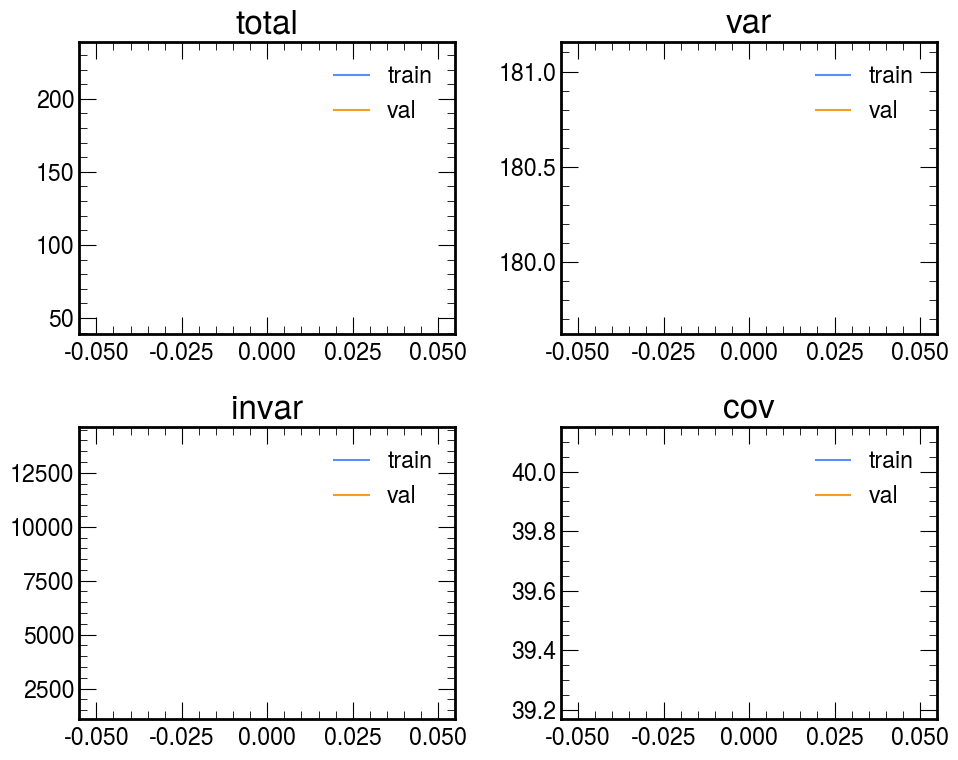

In [74]:
import matplotlib.pyplot as plt
# Create a figure
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
x = np.linspace(0, 10, 100)

# Plot 1
axs[0, 0].plot(train_loss_list["total"], label="train")
axs[0, 0].plot(val_loss_list["total"], label="val")
axs[0, 0].set_title('total')
axs[0, 0].legend()

# Plot 2
axs[0, 1].plot(train_loss_list["var"], label="train")
axs[0, 1].plot(val_loss_list["var"], label="val")
axs[0, 1].set_title('var')
axs[0, 1].legend()

# Plot 3
axs[1, 0].plot(train_loss_list["invar"], label="train")
axs[1, 0].plot(val_loss_list["invar"], label="val")
axs[1, 0].set_title('invar')
axs[1, 0].legend()

# Plot 4
axs[1, 1].plot(train_loss_list["cov"], label="train")
axs[1, 1].plot(val_loss_list["cov"], label="val")
axs[1, 1].set_title('cov')
axs[1, 1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

# Downstream training
Train an MLPF on top of (1) trained VICreg, and (2) a randomly initialized VICReg

In [62]:
# define classification output
CLASS_NAMES_CLIC_LATEX = [
    "none",
    "chhad",
    "nhad",
    r"$\gamma$",
    r"$e^\pm$",
    r"$\mu^\pm$",
]
NUM_CLASSES = len(CLASS_NAMES_CLIC_LATEX)

class MLPF(nn.Module):
    def __init__(
        self,
        input_dim=34,
        width=126,
        num_convs=2,
        k=8,
        embedding_dim=34,
        native_mlpf=False,
    ):
        super(MLPF, self).__init__()

        self.act = nn.ELU
        self.native_mlpf = native_mlpf  # boolean that is true for native mlpf and false for ssl

        if native_mlpf:
            # embedding of the inputs that is necessary for native mlpf training
            self.nn0 = nn.Sequential(
                nn.Linear(input_dim, 126),
                self.act(),
                nn.Linear(126, 126),
                self.act(),
                nn.Linear(126, 126),
                self.act(),
                nn.Linear(126, embedding_dim),
            )

        # GNN that uses the embeddings learnt by VICReg as the input features
        self.conv = nn.ModuleList()
        for i in range(num_convs):
            self.conv.append(
                GravNetConv(
                    embedding_dim,
                    embedding_dim,
                    space_dimensions=4,
                    propagate_dimensions=22,
                    k=k,
                )
            )

        # DNN that acts on the node level to predict the PID
        self.nn = nn.Sequential(
            nn.Linear(embedding_dim, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, NUM_CLASSES),
        )

    def forward(self, batch):

        # unfold the Batch object
        input_ = batch.x.float()
        batch = batch.batch

        # if `native_mlpf` then use then embed the inputs first (otherwise VICReg provides the embeddings)
        if self.native_mlpf:
            embedding = self.nn0(input_)
        else:
            embedding = input_

        # perform a series of graph convolutions
        for num, conv in enumerate(self.conv):
            embedding = conv(embedding, batch)

        # predict the PIDs
        preds_id = self.nn(embedding)

        return preds_id


In [69]:
def compute_weights(target_ids, num_classes):
    """
    computes necessary weights to accomodate class imbalance in the loss function
    """

    vs, cs = torch.unique(target_ids, return_counts=True)
    weights = torch.zeros(num_classes)
    for k, v in zip(vs, cs):
        weights[k] = 1.0 / math.sqrt(float(v))
    # weights[2] = weights[2] * 3  # emphasize nhadrons
    return weights


def train_mlpf(device, train_loader, val_loader, batch_size, model, mode, epochs):

    train_loader = train_loader
    val_loader = val_loader

    lr = 1e-3
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # , momentum= 0.9, weight_decay=1.5e-4)

    patience = 20
    best_val_loss = 99999.9
    stale_epochs = 0

    losses_train, losses_valid = [], []

    vicreg.eval()

    for epoch in tqdm(range(epochs)):

        model.train()
        loss_train = 0
        for batch in tqdm(train_loader):
            if mode == "ssl":
                # make transformation
                tracks, clusters = vicreg.augmentation(batch.to(device))
                
                # ENCODE
                embedding_tracks, embedding_clusters = vicreg.get_embedding(batch)
                tracks.x = embedding_tracks
                clusters.x = embedding_clusters
                
                event = combine_PFelements(tracks, clusters)
                
            elif mode == "native":
                event = batch.to(device)
            
            # make mlpf forward pass
            pred_ids_one_hot = model(event)
            pred_ids = torch.argmax(pred_ids_one_hot, axis=1).to(device)
            target_ids = event.ygen_id.to(torch.long).to(device)

            weights = compute_weights(target_ids, num_classes=6).to(device)  # to accomodate class imbalance
            
            loss = torch.nn.functional.cross_entropy(pred_ids_one_hot, target_ids, weight=weights)  # for classifying PID

            # update parameters
            for param in model.parameters():
                param.grad = None
            loss.backward()
            optimizer.step()

            loss_train += loss.detach()

        model.eval()
        loss_valid = 0
        with torch.no_grad():
            for batch in tqdm(val_loader):
                batch = batch.to(device)
                time.time()
                if mode == "ssl":
                    # make transformation
                    tracks, clusters = vicreg.augmentation(batch.to(device))

                    # ENCODE
                    embedding_tracks, embedding_clusters = vicreg.get_embedding(batch)
                    tracks.x = embedding_tracks
                    clusters.x = embedding_clusters
                    
                    event = combine_PFelements(tracks, clusters)

                elif mode == "native":
                    event = batch.to(device)

                # make mlpf forward pass
                pred_ids_one_hot = model(event)
                pred_ids = torch.argmax(pred_ids_one_hot, axis=1)
                target_ids = event.ygen_id.to(torch.long).to(device)

                weights = compute_weights(
                    target_ids, num_classes=6
                ).to(device)  # to accomodate class imbalance
                loss = torch.nn.functional.cross_entropy(
                    pred_ids_one_hot, target_ids, weight=weights
                )  # for classifying PID

                loss_valid += loss.detach()

        print(
            f"epoch {epoch} - train: {round(loss_train.item(),3)} - valid: {round(loss_valid.item(), 3)} - stale={stale_epochs}")

        losses_train.append(loss_train / len(train_loader))
        losses_valid.append(loss_valid / len(val_loader))

        # early-stopping
        if losses_valid[epoch] < best_val_loss:
            best_val_loss = losses_valid[epoch]
            stale_epochs = 0
        else:
            stale_epochs += 1

    fig, ax = plt.subplots()
    ax.plot(range(len(losses_train[1:])), losses_train[1:], label="training")
    ax.plot(range(len(losses_valid[1:])), losses_valid[1:], label="validation")
    ax.set_xlabel("Epochs", fontsize=15)
    ax.set_ylabel("Loss", fontsize=15)
    ax.legend(title=f"{mode} MLPF", loc="best", title_fontsize=20, fontsize=15)
    return losses_train, losses_valid

Num of model paramaters:  44368


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 24.64it/s]

 10%|█████████████▍                                                                                                                        | 10/100 [00:01<00:16,  5.62it/s]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:10<00:00, 10.75s/it]


epoch 0 - train: 185.754 - valid: 161.924 - stale=0


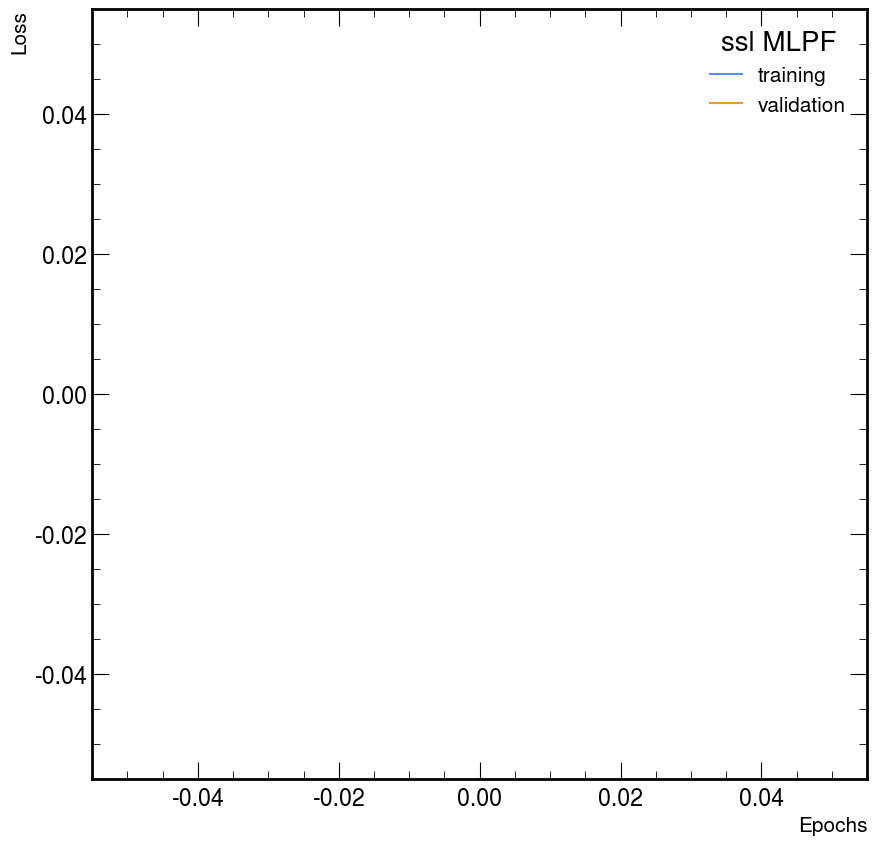

In [70]:
# train ssl version of MLPF
mlpf_ssl = MLPF(embedding_dim=34, native_mlpf=False).to(device)
vicreg = vicreg.to(device)
print("Num of model paramaters: ", sum(p.numel() for p in mlpf_ssl.parameters() if p.requires_grad))

batch_size = 500
epochs=10
losses_train_ssl, losses_valid_ssl = train_mlpf(device, loader["downstream"]["train"], loader["downstream"]["test"], batch_size, mlpf_ssl, mode="ssl", epochs=epochs)

# Results
Comparing the downstream results of randomly initialized VICReg against a trained VICReg

[tensor(1.8575, device='cuda:0')]